<a href="https://colab.research.google.com/github/sofiagracereina/-sofia_INFO5731_Fall2024-/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [49]:
from networkx.algorithms.centrality import load
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from google.colab import files
filepath = 'car_purchase_data.csv'
data = pd.read_csv('car_purchase_data.csv')
display(data.head())
print('Shape:', data.shape)

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [52]:
from pandas.core.algorithms import value_counts
from numpy._core.fromnumeric import shape
# features and target
X = data[['Age','Salary']]
y = data['Purchased']
print('X shape', X.shape)
print('Y distribution:\n', y.value_counts())

X shape (400, 2)
Y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [53]:
from IPython.utils.sysinfo import pprint
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
print('Train Size', X_train.shape[0], 'Test size', X_test.shape[0])

Train Size 300 Test size 100


### Step 4: Feature Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
print('Scaling complete')

Scaling complete


### Step 5: Train Logistic Regression Model

In [55]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)
print('Model Complete')

Model Complete


### Step 6: Predict and Evaluate

In [58]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Confusion Matrix:\n{cm}")
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.8900
Confusion Matrix:
[[65  3]
 [ 8 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



### Step 7: Visualization of Decision Regions

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/tmp/ipykernel_18447/3812831111.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


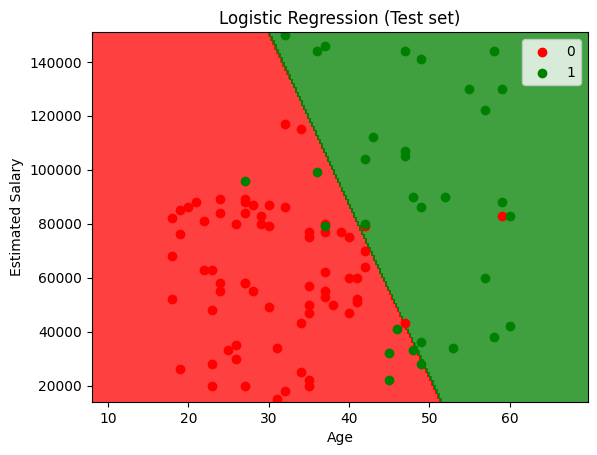

In [25]:
from matplotlib.colors import ListedColormap
import numpy as np

X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Logistic Regression (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here

1. it can still be used for classification with Binary results if you use decision threshold for instance if the calculated probabilty of purchasing is above or equal to 0.5, then it can classifiy the customer as purchased, and less than 0.5 as not purchased.
2. In general the regression model showed older customers with higher slaries were more likely to purchase a car
3. our model had a 89% accuracy but factors that could lower it is few features, assumed linearity for a non-linear pattern, and any underrepresented targets in the data

>

